# Check `oceTAUY` transfer integrity — NEW S3 vs original MIT store (face 1, all dates)

Compares the transferred copy on S3 (`LLC4320_RAW/SURFACE`) against the **original MIT zarr store** (`data.MIT_data_path`) for **face 1 only**, looping through each snapshot date. Plots both sources side by side and flags all-NaN faces.

Notes
-----
* Run this **on the MIT server** — it reads directly from `/orcd/data/abodner/003/LLC4320/LLC4320`.
* The MIT store is one zarr with an hourly `time` dimension; dates are resolved to a time index with `mit_date_to_time_idx`, exactly as the transfer pipeline does.

In [1]:
import sys
from pathlib import Path
from datetime import datetime

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt


def _find_repo_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for cand in (p, *p.parents):
        if (cand / "pyproject.toml").exists():
            return cand
    raise RuntimeError(f"Could not locate repo root (pyproject.toml) above {p}")


REPO = _find_repo_root()
SRC = REPO / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from dbof.llc4320_ingestion.date_iterations import mit_date_to_time_idx

ENDPOINT = "https://s3-west.nrp-nautilus.io"
NEW_TMPL = "dbof/LLC4320_RAW/SURFACE/{stamp}.zarr"
MIT_PATH = "/orcd/data/abodner/003/LLC4320/LLC4320"
VAR = "oceTAUY"
FACE = 1

DATES = [
    "2011-12-09 12:00:00",
    "2012-01-09 12:00:00",
    "2012-02-09 12:00:00",
    "2012-03-09 12:00:00",
    "2012-04-09 12:00:00",
    "2012-05-09 12:00:00",
    "2012-06-09 12:00:00",
    "2012-07-09 12:00:00",
    "2012-08-09 12:00:00",
    "2012-09-09 12:00:00",
    "2012-10-09 12:00:00",
    "2012-11-09 12:00:00",
    "2012-01-01 12:00:00",
    "2012-02-01 12:00:00",
    "2012-03-01 12:00:00",
    "2012-04-01 12:00:00",
    "2012-05-01 12:00:00",
    "2012-06-01 12:00:00",
    "2012-07-01 12:00:00",
    "2012-08-01 12:00:00",
    "2012-09-01 12:00:00",
    "2012-10-01 12:00:00",
    "2012-11-01 12:00:00",
]
DATES = list(dict.fromkeys(DATES))  # 2011-12-09 was listed twice; dedupe

so = {"anon": False,
      "client_kwargs": {"endpoint_url": ENDPOINT},
      "config_kwargs": {"signature_version": "s3v4", "s3": {"addressing_style": "path"}}}

def stamp(date_str):
    return datetime.strptime(date_str, "%Y-%m-%d %H:%M:%S").strftime("%Y%m%dT%H")

In [2]:
# Open the MIT source once (lazy); all dates index into its time dimension.
ds_mit = xr.open_zarr(MIT_PATH, consolidated=False)
NTIME = ds_mit.sizes["time"]
print(f"MIT store: {VAR} dims={ds_mit[VAR].dims} shape={ds_mit[VAR].shape} ntime={NTIME}")

MIT store: oceTAUY dims=('time', 'face', 'j_g', 'i') shape=(10311, 13, 4320, 4320) ntime=10311


In [3]:
def load_new_face(store):
    """Load VAR at FACE from the per-date S3 store (memory-safe), squeezed to 2D."""
    ds = xr.open_zarr("s3://" + store, consolidated=False, storage_options=so)
    return np.squeeze(ds[VAR].isel(face=FACE).values)

def load_mit_face(date_str):
    """Load VAR at FACE for date_str from the MIT store, squeezed to 2D."""
    tidx = mit_date_to_time_idx(date_str, NTIME)
    return np.squeeze(ds_mit[VAR].isel(time=tidx, face=FACE).values), tidx

def stats(x):
    nan_frac = float(np.isnan(x).mean())
    if nan_frac == 1.0:
        return nan_frac, np.nan, np.nan
    return nan_frac, float(np.nanmin(x)), float(np.nanmax(x))

def plot_pair(xa, xb, date):
    finite = np.concatenate([xa[np.isfinite(xa)].ravel(), xb[np.isfinite(xb)].ravel()])
    vmin, vmax = (np.percentile(finite, [1, 99]) if finite.size else (-1, 1))
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
    for ax, x, title in zip(axes, [xa, xb],
                            ["NEW (S3 LLC4320_RAW/SURFACE)", "MIT (orcd source)"]):
        im = ax.imshow(x, origin="lower", vmin=vmin, vmax=vmax, cmap="RdBu_r")
        ax.set_title(f"{title}\n{date}  face {FACE}  NaN={np.isnan(x).mean():.1%}")
        fig.colorbar(im, ax=ax, shrink=0.8)
    plt.show()

# Just MIT


2011-12-09 12:00:00  (20111209T12)
  MIT time_idx = 2100
  MIT: NaN= 21.8%  min=-3.091e-01  max=4.087e-01


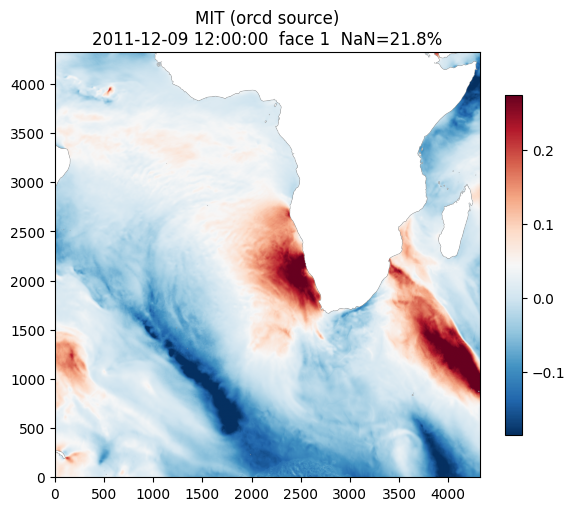


2012-01-09 12:00:00  (20120109T12)
  MIT time_idx = 2844
  MIT: NaN= 21.8%  min=-7.020e-01  max=9.339e-01


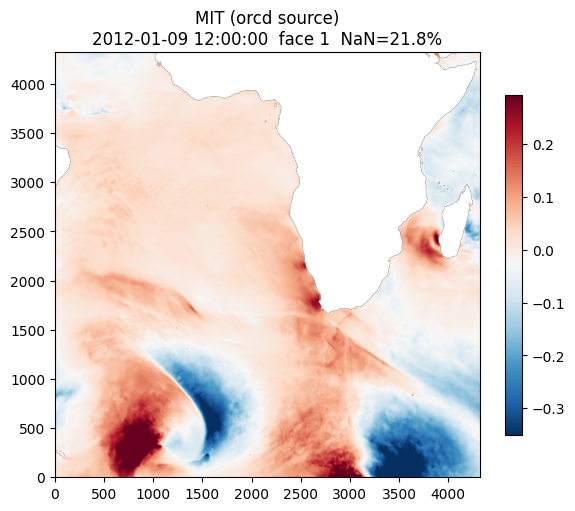


2012-02-09 12:00:00  (20120209T12)
  MIT time_idx = 3588
  MIT: NaN= 21.8%  min=-6.054e-01  max=8.239e-01


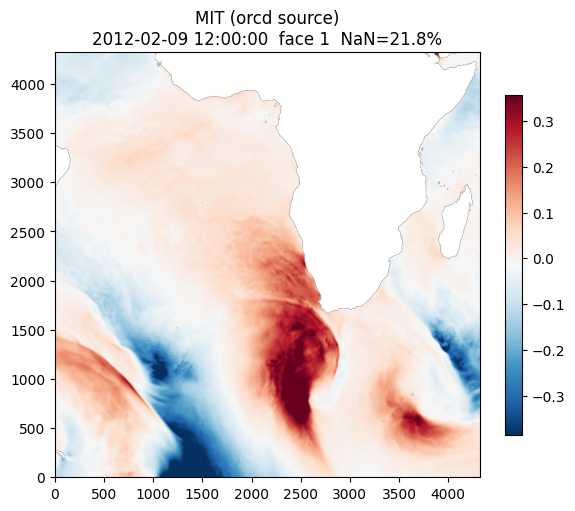


2012-03-09 12:00:00  (20120309T12)
  MIT time_idx = 4284
  MIT: NaN= 21.8%  min=-5.364e-01  max=9.451e-01


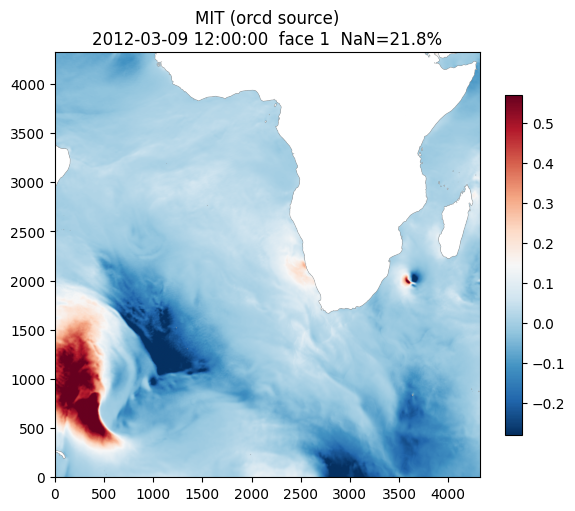


2012-04-09 12:00:00  (20120409T12)
  MIT time_idx = 5028
  MIT: NaN= 21.8%  min=-3.438e-01  max=6.161e-01


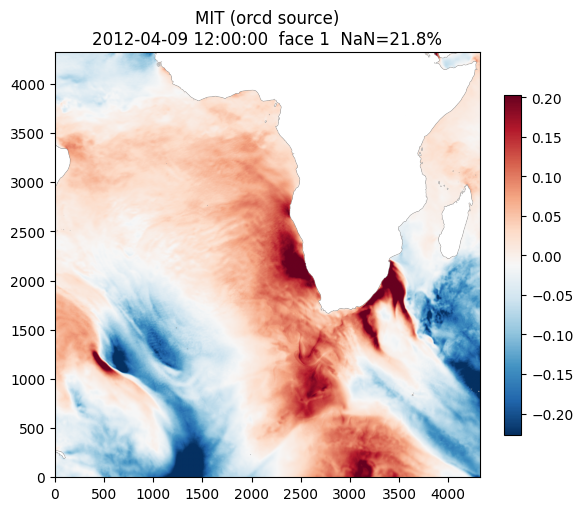


2012-05-09 12:00:00  (20120509T12)
  MIT time_idx = 5748
  MIT: NaN= 21.8%  min=-5.227e-01  max=7.064e-01


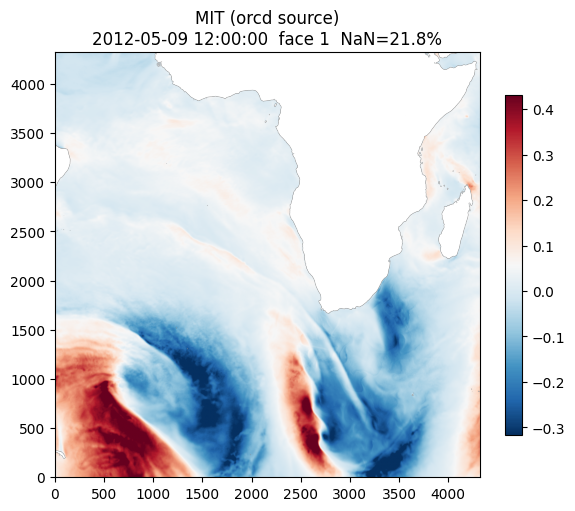


2012-06-09 12:00:00  (20120609T12)
  MIT time_idx = 6492
  MIT: NaN= 21.8%  min=-4.614e-01  max=7.323e-01


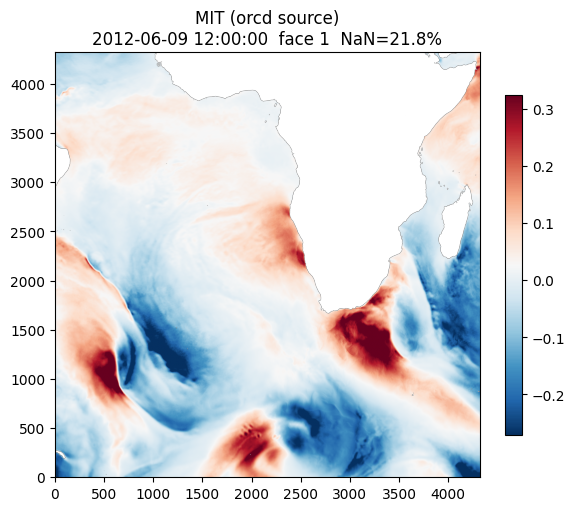


2012-07-09 12:00:00  (20120709T12)
  MIT time_idx = 7212
  MIT: NaN= 21.8%  min=-1.894e+00  max=2.000e+00


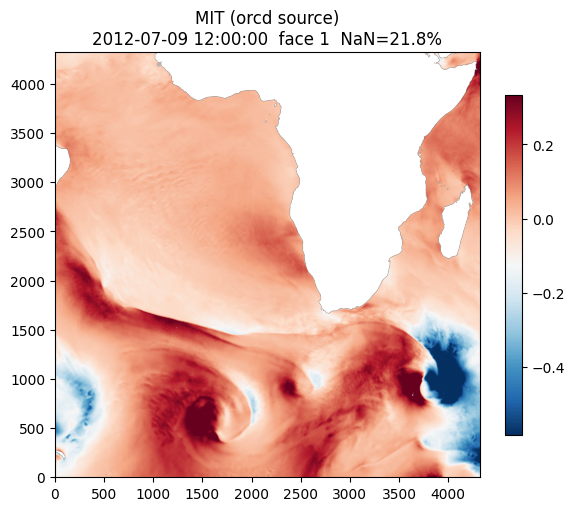


2012-08-09 12:00:00  (20120809T12)
  MIT time_idx = 7956
  MIT: NaN= 21.8%  min=-1.046e+00  max=9.060e-01


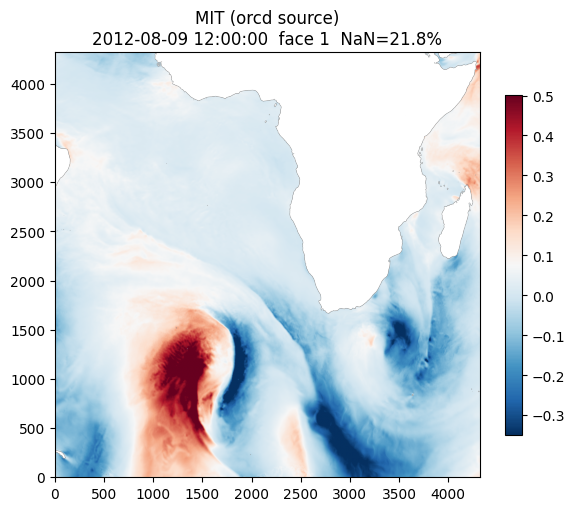


2012-09-09 12:00:00  (20120909T12)
  MIT time_idx = 8700
  MIT: NaN= 21.8%  min=-4.707e-01  max=4.826e-01


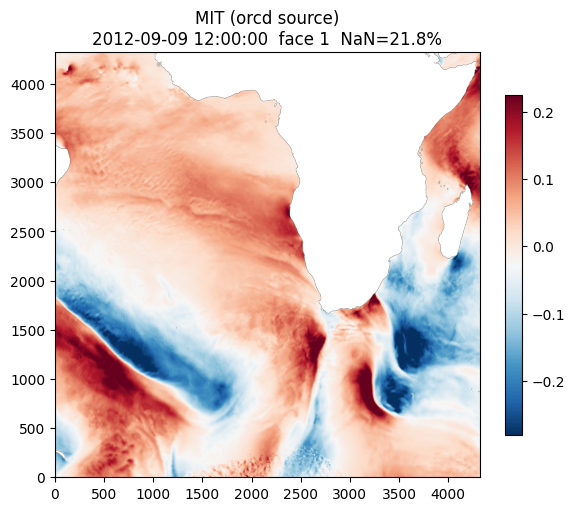


2012-10-09 12:00:00  (20121009T12)
  MIT time_idx = 9420
  MIT: NaN= 21.8%  min=-3.891e-01  max=6.323e-01


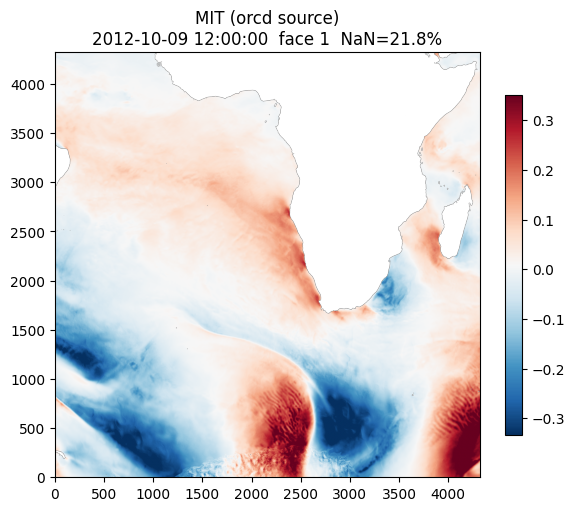


2012-11-09 12:00:00  (20121109T12)
  MIT time_idx = 10164
  MIT: NaN= 21.8%  min=-4.018e-01  max=9.060e-01


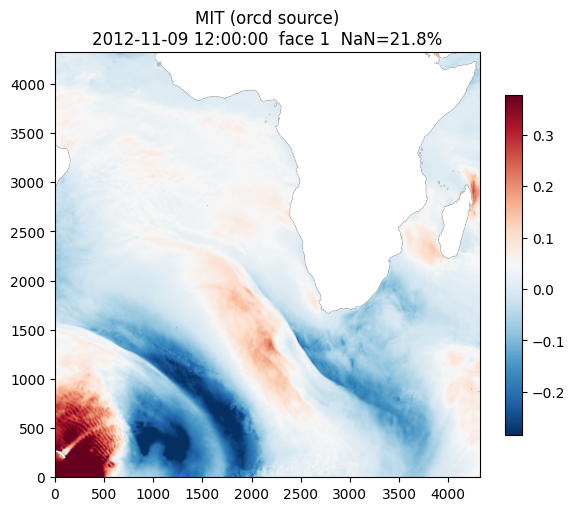


2012-01-01 12:00:00  (20120101T12)
  MIT time_idx = 2652
  MIT: NaN= 21.8%  min=-5.820e-01  max=6.196e-01


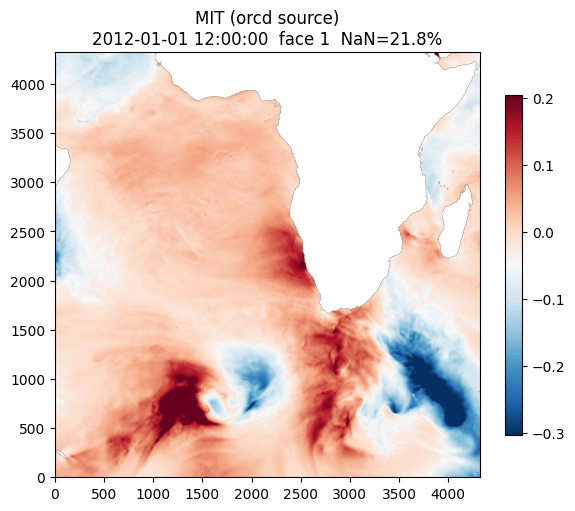


2012-02-01 12:00:00  (20120201T12)
  MIT time_idx = 3396
  MIT: NaN= 21.8%  min=-4.926e-01  max=3.990e-01


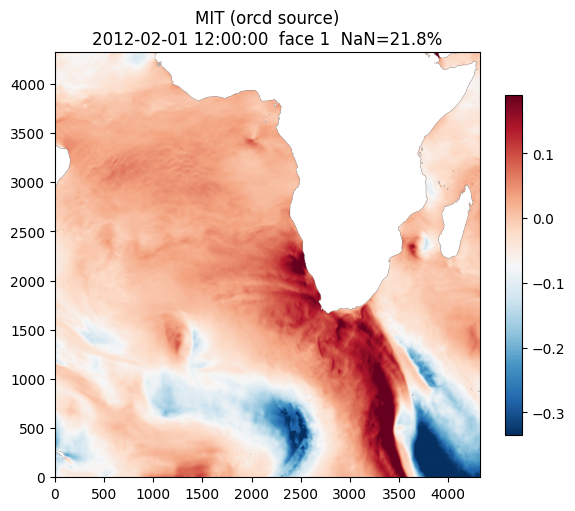


2012-03-01 12:00:00  (20120301T12)
  MIT time_idx = 4092
  MIT: NaN= 21.8%  min=-1.444e+00  max=1.096e+00


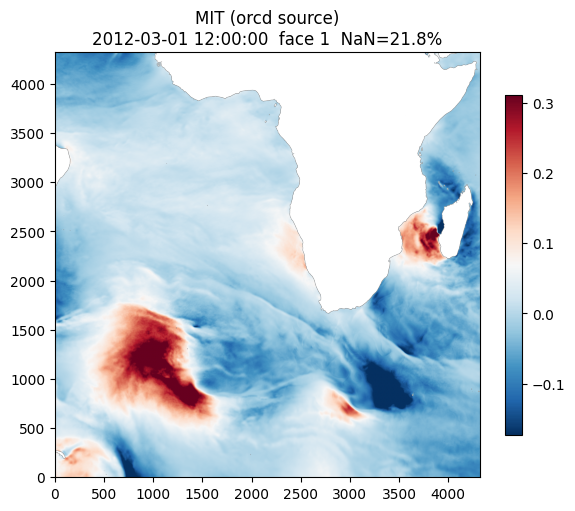


2012-04-01 12:00:00  (20120401T12)
  MIT time_idx = 4836
  MIT: NaN= 21.8%  min=-5.020e-01  max=5.684e-01


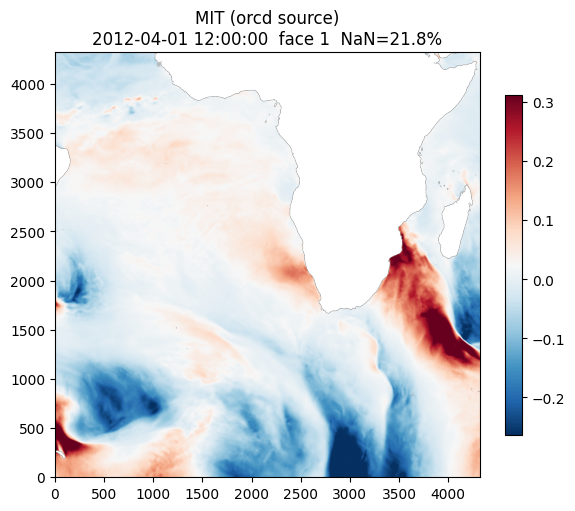


2012-05-01 12:00:00  (20120501T12)
  MIT time_idx = 5556
  MIT: NaN= 21.8%  min=-1.374e+00  max=1.809e+00


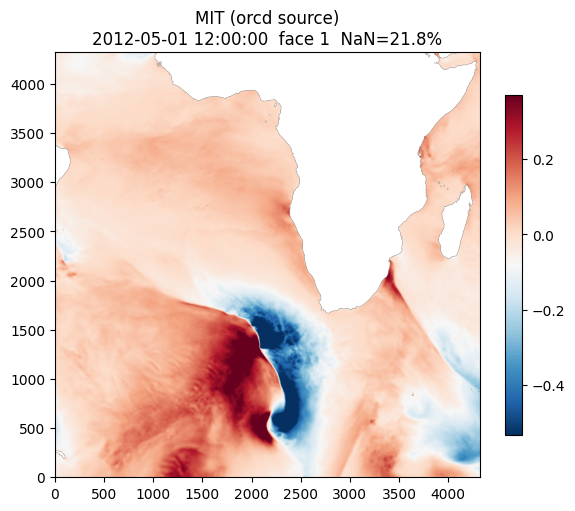


2012-06-01 12:00:00  (20120601T12)
  MIT time_idx = 6300
  MIT: NaN= 21.8%  min=-9.889e-01  max=4.846e-01


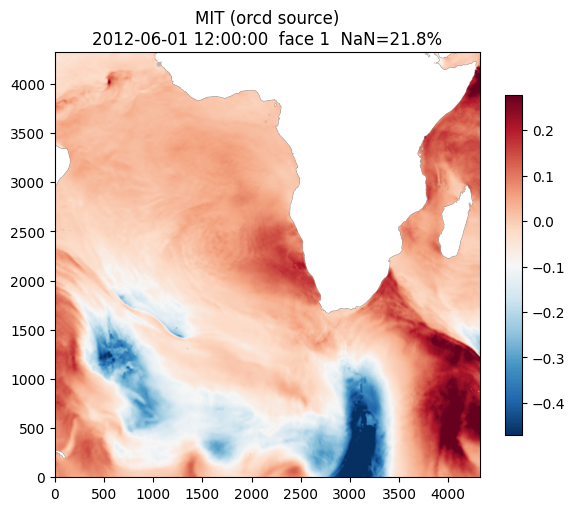


2012-07-01 12:00:00  (20120701T12)
  MIT time_idx = 7020
  MIT: NaN= 21.8%  min=-3.515e-01  max=4.945e-01


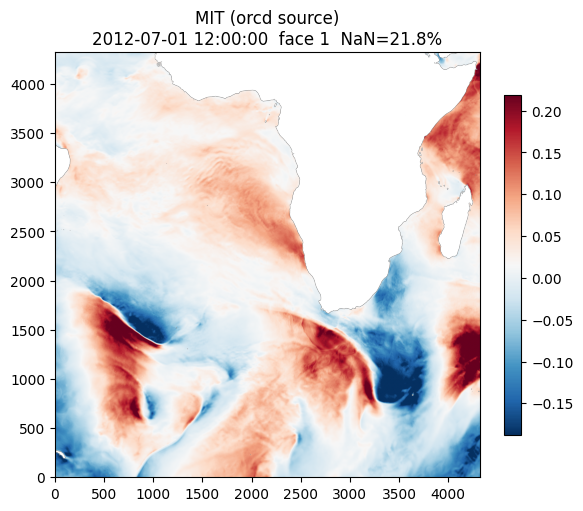


2012-08-01 12:00:00  (20120801T12)
  MIT time_idx = 7764
  MIT: NaN= 21.8%  min=0.000e+00  max=0.000e+00


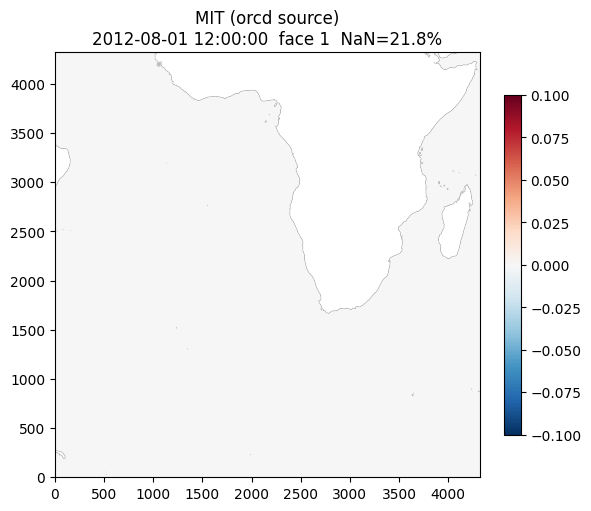


2012-09-01 12:00:00  (20120901T12)
  MIT time_idx = 8508
  MIT: NaN= 21.8%  min=-5.455e-01  max=1.186e+00


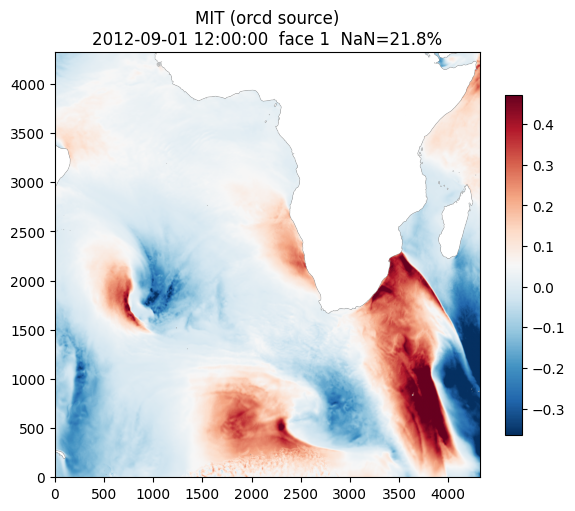


2012-10-01 12:00:00  (20121001T12)
  MIT time_idx = 9228
  MIT: NaN= 21.8%  min=-1.079e+00  max=5.371e-01


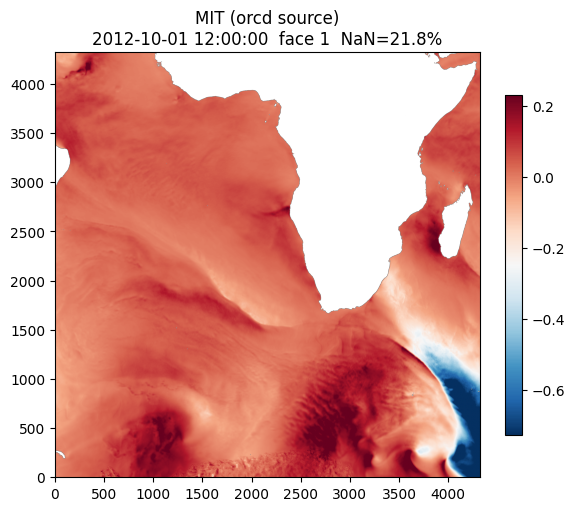


2012-11-01 12:00:00  (20121101T12)
  MIT time_idx = 9972
  MIT: NaN= 21.8%  min=-5.781e-01  max=5.763e-01


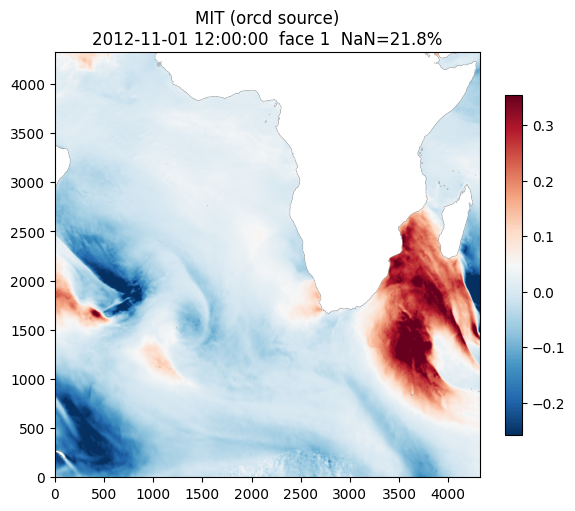

In [5]:
results = []
for date in DATES:
    st = stamp(date)
    print(f"\n{'='*60}\n{date}  ({st})\n{'='*60}")
    try:
        xb, tidx = load_mit_face(date)
        print(f"  MIT time_idx = {tidx}")
    except Exception as e:
        print(f"  LOAD FAILED: {e}")
        results.append(dict(date=date, status="load_failed"))
        continue

    nan_b, min_b, max_b = stats(xb)
    print(f"  MIT: NaN={nan_b:6.1%}  min={min_b:.3e}  max={max_b:.3e}")

    all_nan = nan_b == 1.0
    if all_nan:
        print("  ⚠️  MIT ALL-NaN")

    # single plot, MIT only
    finite = xb[np.isfinite(xb)].ravel()
    vmin, vmax = (np.percentile(finite, [1, 99]) if finite.size else (-1, 1))
    fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
    im = ax.imshow(xb, origin="lower", vmin=vmin, vmax=vmax, cmap="RdBu_r")
    ax.set_title(f"MIT (orcd source)\n{date}  face {FACE}  NaN={nan_b:.1%}")
    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.show()

    results.append(dict(date=date,
                        status="all_nan" if all_nan else "ok",
                        nan_mit=nan_b, min=min_b, max=max_b))

# MIT vs. s3://dbof

In [4]:
results = []
for date in DATES:
    st = stamp(date)
    print(f"\n{'='*60}\n{date}  ({st})\n{'='*60}")
    try:
        xa = load_new_face(NEW_TMPL.format(stamp=st))
        xb, tidx = load_mit_face(date)
        print(f"  MIT time_idx = {tidx}")
    except Exception as e:
        print(f"  LOAD FAILED: {e}")
        results.append(dict(date=date, status="load_failed"))
        continue

    nan_a, min_a, max_a = stats(xa)
    nan_b, min_b, max_b = stats(xb)
    print(f"  NEW: NaN={nan_a:6.1%}  min={min_a:.3e}  max={max_a:.3e}")
    print(f"  MIT: NaN={nan_b:6.1%}  min={min_b:.3e}  max={max_b:.3e}")

    flags = (["NEW ALL-NaN"] if nan_a == 1.0 else []) + (["MIT ALL-NaN"] if nan_b == 1.0 else [])

    if xa.shape != xb.shape:
        print(f"  SHAPE MISMATCH: {xa.shape} vs {xb.shape}")
        identical, max_d, nan_mm = False, np.nan, -1
        flags.append("shape mismatch")
    else:
        identical = np.allclose(xa, xb, equal_nan=True, rtol=0, atol=0)
        nan_mm = int((np.isnan(xa) != np.isnan(xb)).sum())
        d = np.abs(xa - xb)
        max_d = float(np.nanmax(d)) if np.isfinite(d).any() else np.nan
        print(f"  {'IDENTICAL ✅' if identical else f'DIFFERS ❌  max|Δ|={max_d:.3e}  nan-mask mismatches={nan_mm}'}")
    if flags:
        print(f"  ⚠️  {', '.join(flags)}")

    plot_pair(xa, xb, date)

    results.append(dict(date=date,
                        status="identical" if identical else "differs",
                        nan_new=nan_a, nan_mit=nan_b,
                        max_abs_diff=max_d, nan_mask_mismatch=nan_mm,
                        flags=", ".join(flags)))


2011-12-09 12:00:00  (20111209T12)
  LOAD FAILED: [Errno 16] Service Unavailable

2012-01-09 12:00:00  (20120109T12)
  LOAD FAILED: [Errno 16] Service Unavailable

2012-02-09 12:00:00  (20120209T12)


KeyboardInterrupt: 